In [2]:
from scipy.stats import spearmanr, wilcoxon, pearsonr
from scipy.special import kl_div, rel_entr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [3]:
data_h = [	0.3297,	0.1218,	0.2996,	0.6389,
0.4722,		0.4101,	0.9733,	0.2963,
0.281,	0.4238,		0.5972,	0.2685,
0.3661,	0.9963,	0.5685,		0.2995,
0.9414,	0.2821,	0.1786,	0.3822]	
data_gpt = [0.187518752,0.187518752,0.218771877,0.343784378,0.19047619,0.119047619,0.238095238,0.214285714, 0.083333333,0.1875,0.166666667,0.0625,0.166666667,0.958333333,0.1875,0.291666667,0.257997936,0.225748194,0.16124871,0.096749226]
data_bert = [	0.444444444,	0.333333333,	0.222222222,	0.333333333,
0.125,		0.166666667,	0.291666667,	0.145833333,
0.125,	0.25,		0.0625,	0.125,
0.24122807,	1,	0.24122807,		0.270833333,
0.16025641,	0.280448718,	0.16025641,	0.280448718	]

In [4]:
res1 = spearmanr(data_h, data_gpt)
print(res1)
res2 = spearmanr(data_h, data_bert)
print(res2)
res3 = spearmanr(data_bert, data_gpt)
print(res3)

SignificanceResult(statistic=0.45314293092246355, pvalue=0.04480358305046189)
SignificanceResult(statistic=0.20135838222822952, pvalue=0.39460894948221015)
SignificanceResult(statistic=0.511514689965318, pvalue=0.021150813048462357)


In [6]:
res1 = pearsonr(data_h, data_gpt)
print(res1)
res2 = pearsonr(data_h, data_bert)
print(res2)
res3 = pearsonr(data_bert, data_gpt)
print(res3)

PearsonRResult(statistic=0.5883715305336443, pvalue=0.0063552691452647735)
PearsonRResult(statistic=0.41925294612122416, pvalue=0.06575846076175117)
PearsonRResult(statistic=0.890587432170308, pvalue=1.4258289569761582e-07)


In [5]:
res1 = wilcoxon(data_h, data_gpt)
print(res1)
res2 = wilcoxon(data_h, data_bert)
print(res2)
res3 = wilcoxon(data_bert, data_gpt)
print(res3)

WilcoxonResult(statistic=5.0, pvalue=1.9073486328125e-05)
WilcoxonResult(statistic=22.0, pvalue=0.0010166168212890625)
WilcoxonResult(statistic=68.0, pvalue=0.17685317993164062)


In [5]:
import pandas as pd
import numpy as np
#data
data_gpt = {
    'CR': [1, 0.19047619, 0.083333333, 0.166666667, 0.257997936],
    'CZ': [ 0.187518752, 1, 0.1875, 0.958333333, 0.225748194],
    'PO': [ 0.187518752, 0.119047619, 1, 0.1875, 0.16124871],
    'SK': [ 0.218771877, 0.238095238, 0.166666667, 1, 0.096749226],
    'SL': [ 0.343784378, 0.214285714, 0.0625, 0.291666667, 1]
}

index = ['CR', 'CZ', 'PO', 'SK', 'SL']

# Convert to DataFrame
df_gpt = pd.DataFrame(data_gpt, index=index)

data_h = {
    'CR': [1, 0.4722, 0.281, 0.3661, 0.9414],
    'CZ': [0.3297, 1, 0.4239, 0.9963, 0.2821],
    'PO': [0.1218, 0.4101, 1, 0.5685, 0.1786],
    'SK': [0.2996, 0.9733, 0.5972, 1, 0.3822],
    'SL': [0.6389, 0.2963, 0.2685, 0.2995, 1]
}

# Convert to DataFrame
df_h = pd.DataFrame(data_h, index=index)

print(df_gpt)
print(df_h)

          CR        CZ        PO        SK        SL
CR  1.000000  0.187519  0.187519  0.218772  0.343784
CZ  0.190476  1.000000  0.119048  0.238095  0.214286
PO  0.083333  0.187500  1.000000  0.166667  0.062500
SK  0.166667  0.958333  0.187500  1.000000  0.291667
SL  0.257998  0.225748  0.161249  0.096749  1.000000
        CR      CZ      PO      SK      SL
CR  1.0000  0.3297  0.1218  0.2996  0.6389
CZ  0.4722  1.0000  0.4101  0.9733  0.2963
PO  0.2810  0.4239  1.0000  0.5972  0.2685
SK  0.3661  0.9963  0.5685  1.0000  0.2995
SL  0.9414  0.2821  0.1786  0.3822  1.0000


In [6]:
# Function to compute ranks for each language
def compute_ranks(df):
    ranked_df = pd.DataFrame()
    for subject in df.columns[:]:
        ranked_df[subject + '_Rank'] = df[subject].rank(ascending=False)
    return ranked_df

# Compute ranks for both classes
ranked_gpt = compute_ranks(df_gpt)
ranked_h = compute_ranks(df_h)

print(ranked_gpt)
print(ranked_h)

    CR_Rank  CZ_Rank  PO_Rank  SK_Rank  SL_Rank
CR      1.0      4.0      2.0      3.0      2.0
CZ      3.0      1.0      5.0      2.0      4.0
PO      5.0      5.0      1.0      4.0      5.0
SK      4.0      2.0      3.0      1.0      3.0
SL      2.0      3.0      4.0      5.0      1.0
    CR_Rank  CZ_Rank  PO_Rank  SK_Rank  SL_Rank
CR      1.0      4.0      5.0      5.0      2.0
CZ      3.0      1.0      3.0      2.0      4.0
PO      5.0      3.0      1.0      3.0      5.0
SK      4.0      2.0      2.0      1.0      3.0
SL      2.0      5.0      4.0      4.0      1.0


In [7]:
# Compute correlation of ranks between subjects for each class
correlation_gpt = ranked_gpt[['CR_Rank', 'CZ_Rank', 'PO_Rank', 'SK_Rank', 'SL_Rank']].corr()
correlation_h = ranked_h[['CR_Rank', 'CZ_Rank', 'PO_Rank', 'SK_Rank', 'SL_Rank']].corr()

# Print the correlation matrices
print("Correlation matrix for gpt:")
print(correlation_gpt)
print("\nCorrelation matrix for human:")
print(correlation_h)

# Compare patterns (you can use visual methods or specific metrics)
pattern_similarity = np.allclose(correlation_gpt.values, correlation_h.values, rtol=1e-1)
print("\nDo the classes show similar correlation patterns?:", pattern_similarity)


Correlation matrix for gpt:
         CR_Rank  CZ_Rank  PO_Rank  SK_Rank  SL_Rank
CR_Rank      1.0      0.1     -0.3     -0.2      0.8
CZ_Rank      0.1      1.0     -0.9      0.6      0.1
PO_Rank     -0.3     -0.9      1.0     -0.2     -0.3
SK_Rank     -0.2      0.6     -0.2      1.0     -0.3
SL_Rank      0.8      0.1     -0.3     -0.3      1.0

Correlation matrix for human:
         CR_Rank  CZ_Rank  PO_Rank  SK_Rank  SL_Rank
CR_Rank      1.0     -0.5     -1.0     -0.7      0.8
CZ_Rank     -0.5      1.0      0.5      0.8     -0.7
PO_Rank     -1.0      0.5      1.0      0.7     -0.8
SK_Rank     -0.7      0.8      0.7      1.0     -0.5
SL_Rank      0.8     -0.7     -0.8     -0.5      1.0

Do the classes show similar correlation patterns?: False


In [10]:
correlation_gpt_base = df_gpt.corr(method='kendall')
correlation_h_base = df_h.corr(method='kendall')

# Print the correlation matrices
print("Correlation matrix for gpt:")
print(correlation_gpt_base)
print("\nCorrelation matrix for human:")
print(correlation_h_base)

Correlation matrix for gpt:
     CR   CZ   PO   SK   SL
CR  1.0  0.0 -0.2 -0.2  0.6
CZ  0.0  1.0 -0.8  0.4  0.0
PO -0.2 -0.8  1.0 -0.2 -0.2
SK -0.2  0.4 -0.2  1.0 -0.2
SL  0.6  0.0 -0.2 -0.2  1.0

Correlation matrix for human:
     CR   CZ   PO   SK   SL
CR  1.0 -0.2 -1.0 -0.6  0.6
CZ -0.2  1.0  0.2  0.6 -0.6
PO -1.0  0.2  1.0  0.6 -0.6
SK -0.6  0.6  0.6  1.0 -0.2
SL  0.6 -0.6 -0.6 -0.2  1.0


In [4]:
# KL Divergence

bert = [1, 0.444444444,0.333333333,0.222222222,0.333333333]
human  = [1, 0.3297,0.1218,0.2996,0.6389]

bert /= np.sum(bert)
human /= np.sum(human)

kl_1 = kl_div(bert, human)
kl_2 = kl_div(human, bert)

print(kl_1)
print(kl_2)

print(np.sum(kl_1))
print(np.sum(kl_2))

[0.0001224  0.00892835 0.05535636 0.00394852 0.0349494 ]
[0.00012143 0.00801864 0.03936495 0.00432703 0.04304157]
0.10330502671793873
0.09487360840280099


In [5]:
bert /= np.sum(bert)
human /= np.sum(human)

v = rel_entr(bert, human)
kldiv = np.sum(v)

print(kldiv)

0.10330502671793867


In [6]:
# KL Divergence

bert = [0.444444444,0.333333333,0.222222222,0.333333333]
human  = [0.3297,0.1218,0.2996,0.6389]

bert /= np.sum(bert)
human /= np.sum(human)

kl_1 = kl_div(bert, human)
kl_2 = kl_div(human, bert)

print(kl_1)
print(kl_2)

print(np.sum(kl_1))
print(np.sum(kl_2))

[0.01728211 0.09972198 0.00601479 0.05739447]
[0.01543052 0.07050848 0.00655282 0.07027296]
0.180413336783317
0.16276478742268


In [7]:
langs = ["CR", "CZ", "PO", "SK", "SL"]

data_h =   [[1,	0.3297,	0.1218,	0.2996,	0.6389],
            [1,0.4722,		0.4101,	0.9733,	0.2963],
            [1,0.281,	0.4238,		0.5972,	0.2685],
            [1,0.3661,	0.9963,	0.5685,		0.2995],
            [1,0.9414,	0.2821,	0.1786,	0.3822]]	
data_gpt = [[1,0.187518752,0.187518752,0.218771877,0.343784378],
            [1,0.19047619,0.119047619,0.238095238,0.214285714], 
            [1,0.083333333,0.1875,0.166666667,0.0625],
            [1,0.166666667,0.958333333,0.1875,0.291666667],
            [1,0.257997936,0.225748194,0.16124871,0.096749226]]
data_bert = [[1,	0.444444444,	0.333333333,	0.222222222,	0.333333333],
            [1,0.125,		0.166666667,	0.291666667,	0.145833333],
            [1,0.125,	0.25,		0.0625,	0.125],
            [1,0.24122807,	1,	0.24122807,		0.270833333],
            [1,0.16025641,	0.280448718,	0.16025641,	0.280448718]]

klsum_gpt = []
klsum_bert = []

for i in range(5):
    h = data_h[i]/np.sum(data_h[i])
    g = data_gpt[i]/np.sum(data_gpt[i])
    b = data_bert[i]/np.sum(data_bert[i])
    #softmax normalize
    
    kl_g = np.sum(kl_div(h, g))
    kl_b = np.sum(kl_div(h, b))
    
    klsum_gpt.append(kl_g)
    klsum_bert.append(kl_b)
    
    print(langs[i])
    print("GPT:",kl_g)
    print("BERT:",kl_b)
    print()
    
print("Average")
print("GPT:",np.average(klsum_gpt))
print("BERT:",np.average(klsum_bert))

CR
GPT: 0.05109160808405756
BERT: 0.09487360840280099

CZ
GPT: 0.18059355245543873
BERT: 0.15467286148032483

PO
GPT: 0.17746165827063862
BERT: 0.2820011607874696

SK
GPT: 0.08333277798232133
BERT: 0.046516197821754354

SL
GPT: 0.1862634376015116
BERT: 0.2567192962912651

Average
GPT: 0.13574860687879356
BERT: 0.16695662495672298


In [8]:
h = [1,0.281,	0.4238,		0.5972,	0.2685]
gpt = [1,0.083333333,0.1875,0.166666667,0.0625]
gpt_t = [1, 0.083333333, 0.22917, 0.14583, 0.16666666]

h /= np.sum(h)
gpt /= np.sum(gpt)
gpt_t /= np.sum(gpt_t)

print("Base",np.sum(kl_div(h, gpt)))
print("Trns",np.sum(kl_div(h, gpt_t)))
print("Comp",np.sum(kl_div(gpt, gpt_t)))

Base 0.17746165827063862
Trns 0.15299378025627336
Comp 0.028928525755182247


In [9]:
a = [1,2,3]
b = [2,4,6]

print(kl_div(a, b))

a /= np.sum(a)
b /= np.sum(b)

print(kl_div(a, b))

[0.30685282 0.61370564 0.92055846]
[0. 0. 0.]


In [10]:
a = [1,2,3]
b = [0.5,1,1.5]

print(kl_div(a, b))

a /= np.sum(a)
b /= np.sum(b)

print(kl_div(a, b))

[0.19314718 0.38629436 0.57944154]
[0. 0. 0.]


In [11]:
a = [1,2,3]
b = [2,4,2]

cos_sim = np.dot(a, b)/(np.linalg.norm(a)*np.linalg.norm(b))

print(cos_sim)

0.8728715609439696


In [1]:
def create_rel_matrix(m):
    rm = []

    for i in m:
        temp = []
        for x in range(len(i)-1):
            for y in range(x+1, len(i)):
                r = i[x]/i[y]
                if r > 1: r = 1/r
                temp.append(r)
        rm.append(temp)

    return rm

def cos_sim(a,b):
    return np.dot(a, b)/(np.linalg.norm(a)*np.linalg.norm(b))

In [2]:

#Data with self scores
data_h =   [[1,	0.3297,	0.1218,	0.2996,	0.6389],
            [0.4722, 1, 0.4101,	0.9733,	0.2963],
            [0.281,	0.4238, 1,		0.5972,	0.2685],
            [0.3661,	0.9963,	0.5685,	1,	0.2995],
            [0.9414,	0.2821,	0.1786,	0.3822, 1]]	
data_gpt = [[1,0.187518752,0.187518752,0.218771877,0.343784378],
            [0.19047619,1,0.119047619,0.238095238,0.214285714], 
            [0.083333333,0.1875,1,0.166666667,0.0625],
            [0.166666667,0.958333333,0.1875,1,0.291666667],
            [0.257997936,0.225748194,0.16124871,0.096749226,1]]
data_bert = [[1,	0.444444444,	0.333333333,	0.222222222,	0.333333333],
            [0.125,1,		0.166666667,	0.291666667,	0.145833333],
            [0.125,	0.25,1,		0.0625,	0.125],
            [0.24122807,	1,	0.24122807,1,		0.270833333],
            [0.16025641,	0.280448718,	0.16025641,	0.280448718,1]]


In [6]:
langs = ["CR", "CZ", "PO", "SK", "SL"]

#Data without self scores
data_h =   [[0.3297,	0.1218,	0.2996,	0.6389],
            [0.4722,  0.4101,	0.9733,	0.2963],
            [0.281,	0.4238, 		0.5972,	0.2685],
            [0.3661,	0.9963,	0.5685,		0.2995],
            [0.9414,	0.2821,	0.1786,	0.3822]]	
data_gpt = [[0.187518752,0.187518752,0.218771877,0.343784378],
            [0.19047619,0.119047619,0.238095238,0.214285714], 
            [0.083333333,0.1875,0.166666667,0.0625],
            [0.166666667,0.958333333,0.1875,0.291666667],
            [0.257997936,0.225748194,0.16124871,0.096749226]]
data_bert = [[	0.444444444,	0.333333333,	0.222222222,	0.333333333],
            [0.125,		0.166666667,	0.291666667,	0.145833333],
            [0.125,	0.25,		0.0625,	0.125],
            [0.24122807,	1,	0.24122807,		0.270833333],
            [0.16025641,	0.280448718,	0.16025641,	0.280448718]]

rm_h = create_rel_matrix(data_h)
rm_g = create_rel_matrix(data_gpt)
rm_b = create_rel_matrix(data_bert)

for i in range(5):
    print(langs[i])
    print()
    print(rm_h[i])
    print(rm_g[i])
    print(rm_b[i])
    print()
    print("Cosine(GPT):", cos_sim(data_h[i],data_gpt[i]))
    print("Cosine(Rel GPT):", cos_sim(rm_h[i],rm_g[i]))
    print("KL Divergence(GPT):", np.average(kl_div(rm_h[i],rm_g[i])))
    print()
    print("Cosine(BERT):", cos_sim(data_h[i],data_bert[i]))
    print("Cosine(Rel BERT):", cos_sim(rm_h[i],rm_b[i]))
    print("KL Divergence(BERT):", np.average(kl_div(rm_h[i],rm_b[i])))
    print()

CR

[0.3694267515923567, 0.9087048832271762, 0.5160431992487087, 0.4065420560747664, 0.19064016277977774, 0.46893097511347626]
[1.0, 0.857142858448849, 0.545454546512291, 0.857142858448849, 0.545454546512291, 0.6363636366280727]
[0.75, 0.5, 0.75, 0.6666666666666666, 1.0, 0.6666666666666666]

Cosine(GPT): 0.9649620519653354
Cosine(Rel GPT): 0.9114098598678702
KL Divergence(GPT): 0.09850799923301046

Cosine(BERT): 0.8642721430749235
Cosine(Rel BERT): 0.8155999911140438
KL Divergence(BERT): 0.14655909819131305

CZ

[0.8684879288437103, 0.4851536011507243, 0.6274883523930538, 0.4213500462344601, 0.7225067056815411, 0.3044282338436248]
[0.6250000013125, 0.79999999832, 0.8888888878518518, 0.5, 0.555555556074074, 0.8999999991600001]
[0.7499999985000001, 0.4285714280816327, 0.8571428591020408, 0.5714285719183674, 0.8749999962500001, 0.4999999982857143]

Cosine(GPT): 0.9288654385160992
Cosine(Rel GPT): 0.901514452242723
KL Divergence(GPT): 0.07539002877326802

Cosine(BERT): 0.9834044405977747
C

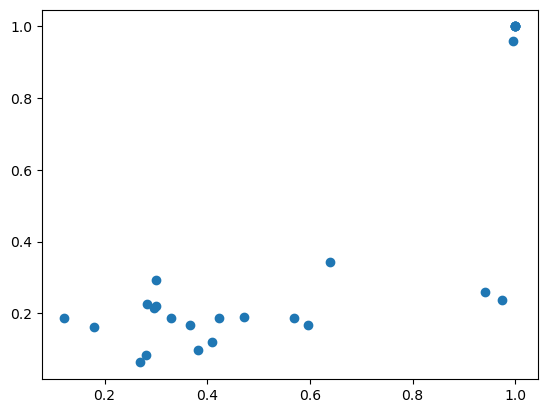

In [3]:
plt.scatter(data_h, data_gpt)
plt.show()

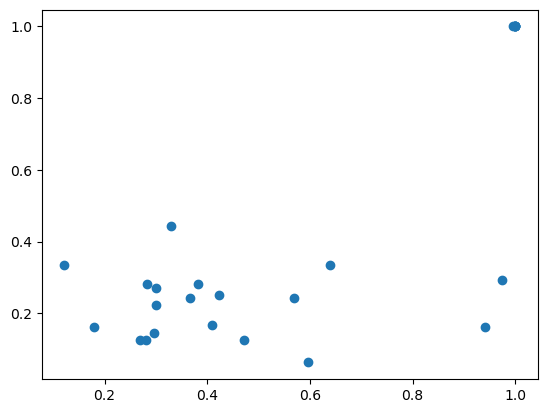

In [4]:
plt.scatter(data_h, data_bert)
plt.show()

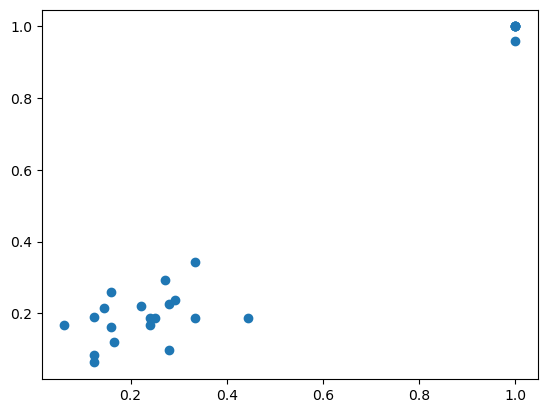

In [5]:
plt.scatter(data_bert, data_gpt)
plt.show()

(array([0.83905252, 0.00661225]), array([0.13434695]), 2, array([1.34488635, 0.4373565 ]), 4.440892098500626e-15)
 
0.8391 x + 0.006612


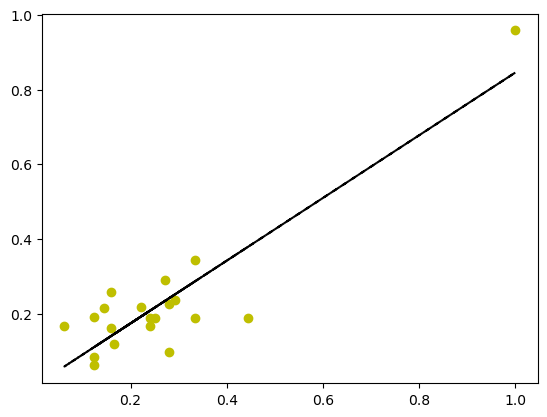

In [24]:
data_h =   [[0.3297,	0.1218,	0.2996,	0.6389],
            [0.4722,  0.4101,	0.9733,	0.2963],
            [0.281,	0.4238, 		0.5972,	0.2685],
            [0.3661,	0.9963,	0.5685,		0.2995],
            [0.9414,	0.2821,	0.1786,	0.3822]]	
data_gpt = [[0.187518752,0.187518752,0.218771877,0.343784378],
            [0.19047619,0.119047619,0.238095238,0.214285714], 
            [0.083333333,0.1875,0.166666667,0.0625],
            [0.166666667,0.958333333,0.1875,0.291666667],
            [0.257997936,0.225748194,0.16124871,0.096749226]]
data_bert = [[	0.444444444,	0.333333333,	0.222222222,	0.333333333],
            [0.125,		0.166666667,	0.291666667,	0.145833333],
            [0.125,	0.25,		0.0625,	0.125],
            [0.24122807,	1,	0.24122807,		0.270833333],
            [0.16025641,	0.280448718,	0.16025641,	0.280448718]]

x = data_bert
y = data_gpt
#https://stackoverflow.com/questions/6148207/linear-regression-with-matplotlib-numpy
coef = np.polyfit(list(itertools.chain(*x)),list(itertools.chain(*y)),1)
poly1d_fn = np.poly1d(coef) 

#print values for info
print(np.polyfit(list(itertools.chain(*x)),list(itertools.chain(*y)),1, full = True))
print(poly1d_fn)

plt.plot(x,y, 'yo', x, poly1d_fn(x), '--k')

plt.show()

(array([0.4235705 , 0.03397195]), array([0.42464041]), 2, array([1.36995051, 0.35104927]), 4.440892098500626e-15)
 
0.4236 x + 0.03397


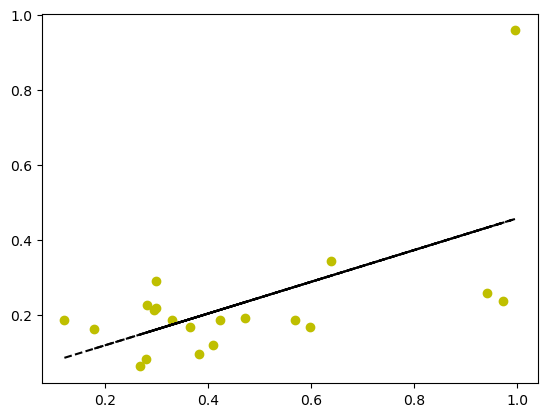

In [25]:
data_h =   [[0.3297,	0.1218,	0.2996,	0.6389],
            [0.4722,  0.4101,	0.9733,	0.2963],
            [0.281,	0.4238, 		0.5972,	0.2685],
            [0.3661,	0.9963,	0.5685,		0.2995],
            [0.9414,	0.2821,	0.1786,	0.3822]]	
data_gpt = [[0.187518752,0.187518752,0.218771877,0.343784378],
            [0.19047619,0.119047619,0.238095238,0.214285714], 
            [0.083333333,0.1875,0.166666667,0.0625],
            [0.166666667,0.958333333,0.1875,0.291666667],
            [0.257997936,0.225748194,0.16124871,0.096749226]]
data_bert = [[	0.444444444,	0.333333333,	0.222222222,	0.333333333],
            [0.125,		0.166666667,	0.291666667,	0.145833333],
            [0.125,	0.25,		0.0625,	0.125],
            [0.24122807,	1,	0.24122807,		0.270833333],
            [0.16025641,	0.280448718,	0.16025641,	0.280448718]]

x = data_h
y = data_gpt

coef = np.polyfit(list(itertools.chain(*x)),list(itertools.chain(*y)),1)
poly1d_fn = np.poly1d(coef)

print(np.polyfit(list(itertools.chain(*x)),list(itertools.chain(*y)),1, full = True))
print(poly1d_fn)

plt.plot(x,y, 'yo', x, poly1d_fn(x), '--k')

plt.show()

(array([0.32035949, 0.11678733]), array([0.60309465]), 2, array([1.36995051, 0.35104927]), 4.440892098500626e-15)
 
0.3204 x + 0.1168


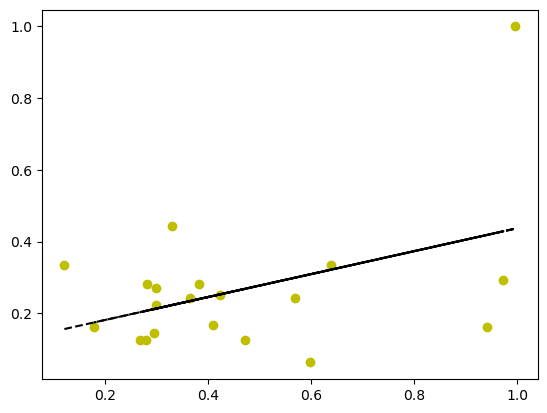

In [26]:
data_h =   [[0.3297,	0.1218,	0.2996,	0.6389],
            [0.4722,  0.4101,	0.9733,	0.2963],
            [0.281,	0.4238, 		0.5972,	0.2685],
            [0.3661,	0.9963,	0.5685,		0.2995],
            [0.9414,	0.2821,	0.1786,	0.3822]]	
data_gpt = [[0.187518752,0.187518752,0.218771877,0.343784378],
            [0.19047619,0.119047619,0.238095238,0.214285714], 
            [0.083333333,0.1875,0.166666667,0.0625],
            [0.166666667,0.958333333,0.1875,0.291666667],
            [0.257997936,0.225748194,0.16124871,0.096749226]]
data_bert = [[	0.444444444,	0.333333333,	0.222222222,	0.333333333],
            [0.125,		0.166666667,	0.291666667,	0.145833333],
            [0.125,	0.25,		0.0625,	0.125],
            [0.24122807,	1,	0.24122807,		0.270833333],
            [0.16025641,	0.280448718,	0.16025641,	0.280448718]]

x = data_h
y = data_bert

coef = np.polyfit(list(itertools.chain(*x)),list(itertools.chain(*y)),1)
poly1d_fn = np.poly1d(coef) 

print(np.polyfit(list(itertools.chain(*x)),list(itertools.chain(*y)),1, full = True))
print(poly1d_fn)

plt.plot(x,y, 'yo', x, poly1d_fn(x), '--k')

plt.show()